# **Image Sharpening using a Single Spatial Filter**

**Course:** Signal and Image Processing  
**Academic Year:** 2025/2026  
**Student:** Irene Marrali          
**Image:** `boat_small.jpg`.

## General Objective
The goal of this assignment is to implement image sharpening by designing a single appropriate image filter.

Image sharpening is an image enhancement technique used to **make edges and fine details more visible.** In this notebook, the sharpening filter is built starting from a **Gaussian filter and an identity filter.** The Gaussian filter represents a smoothing operation, while the identity filter preserves the original pixel values.

The final sharpening filter is obtained by combining these two filters as follows:

\\[h_{\text{sharpen}} = h_{\text{identity}} + (h_{\text{identity}} - h_{\text{gaussian}})\\]


This formulation enhances the high-frequency components of the image, such as edges and details, while **preserving the overall structure of the original image.**

## Initial Setup and Image Import

The image `boat_small.jpg` is imported and converted to grayscale, following the approach used in the reference notebook. Working with a grayscale image allows the sharpening filter to be applied to a single intensity channel.

The original image is visualized before applying any filtering operation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.util import img_as_float
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving boat_small.jpg to boat_small.jpg


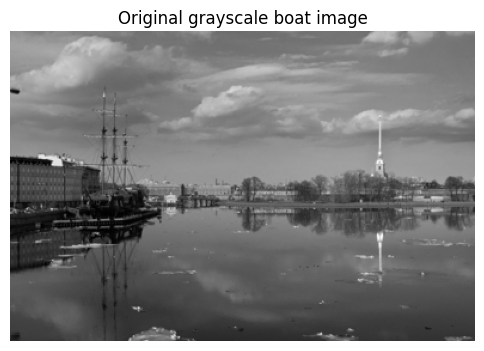

In [ ]:
# Import the image and convert it to grayscale
boat = imread("boat_small.jpg", as_gray=True)
# Convert the image to floating point format
# Pixel values are scaled in the range [0, 1], which is useful for filtering operations
boat = img_as_float(boat)

plt.figure(figsize=(6, 6)) # Create a figure for displaying the original grayscale image
plt.imshow(boat, cmap="gray")  # Display the grayscale image using the gray colormap
plt.title("Original grayscale boat image") # Add a title to the displayed image
plt.axis("off")
plt.show() # Show the figure

The image contains **several fine details**, especially in the ship structure, the buildings, the church tower and the reflections on the water. These areas are useful for evaluating the effect of the sharpening filter, because edges and thin structures should become more visible after filtering.

At the same time, the image also contains **smooth regions**, such as the sky and the water surface. For this reason, the sharpening operation should be moderate, in order to enhance details **without introducing excessive noise or artificial artifacts.**

## Gaussian and Identity Filter Creation

In this section, the two filters needed to build the final sharpening filter are created: **the Gaussian filter and the identity filter.**

* The Gaussian filter is used as the smoothing component. It represents a local averaging operation, where the central pixels have a higher weight and the surrounding pixels have progressively lower weights.
* The identity filter, instead, keeps the original image unchanged and will be used as the reference filter for the sharpening operation.

### Gaussian Filter
The Gaussian filter is created by starting from an impulse image, which is a small matrix containing zeros everywhere except for a value of 1 in the center.

A Gaussian function is then applied to this impulse. In this way, the single central value is spread around the neighborhood, creating a smooth and symmetric filter.

In this implementation, a \\(7 \times 7\\) filter with \\(\sigma = 1.2\\) is used. This choice gives a **slightly stronger sharpening** effect than a smaller \\(5 \times 5\\) filter, while still avoiding an excessively artificial result.

In [ ]:
# Create the Gaussian filter

# Define the size of the filter
filter_size = 7 # A value of 7 means that the filter will be a 7x7 matrix

# Define the standard deviation of the Gaussian function
sigma = 1.2

impulse = np.zeros((filter_size, filter_size)) # Create a 7x7 matrix filled with zeros
center = filter_size // 2 # Compute the index of the center of the filter
impulse[center, center] = 1 # Set the central value of the impulse image to 1

# Apply a Gaussian filter to the impulse image
h_gaussian = gaussian_filter(impulse, sigma=sigma)
# Normalize the Gaussian filter so that the sum of all coefficients is equal to 1
h_gaussian = h_gaussian / np.sum(h_gaussian)

print("Gaussian filter:")
print(np.round(h_gaussian, 4)) # Print the Gaussian filter values rounded to 4 decimal places

Gaussian filter:
[[0.0003 0.0013 0.0037 0.0053 0.0037 0.0013 0.0003]
 [0.0013 0.0069 0.0195 0.0276 0.0195 0.0069 0.0013]
 [0.0037 0.0195 0.0552 0.0781 0.0552 0.0195 0.0037]
 [0.0053 0.0276 0.0781 0.1105 0.0781 0.0276 0.0053]
 [0.0037 0.0195 0.0552 0.0781 0.0552 0.0195 0.0037]
 [0.0013 0.0069 0.0195 0.0276 0.0195 0.0069 0.0013]
 [0.0003 0.0013 0.0037 0.0053 0.0037 0.0013 0.0003]]


The printed values show that the Gaussian filter **gives the highest weight to the central pixel,** while the weights decrease as the distance from the center increases.

The filter is also normalized, so the sum of all its coefficients is equal to 1. This is important because the Gaussian filter performs smoothing without strongly changing the global brightness of the image.

The Gaussian filter can also be visualized as an image. This makes it easier to understand its spatial structure: **brighter values correspond to larger coefficients, while darker values correspond to smaller coefficients.**

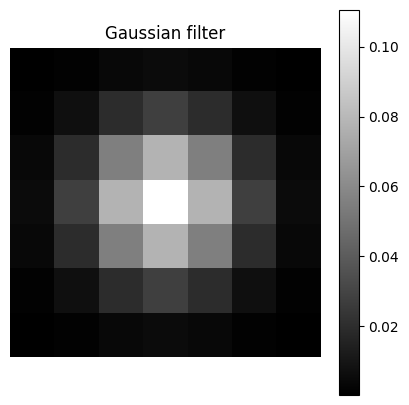

In [ ]:
# Visualize the Gaussian filter
plt.figure(figsize=(5, 5)) # Create a new figure
plt.imshow(h_gaussian, cmap="gray") # Display the Gaussian filter as an image
plt.title("Gaussian filter") # Add a title to the filter visualization
plt.colorbar() # Add a colorbar to show the numerical scale of the filter values
plt.axis("off")
plt.show() # Show the figure

### Identity Filter

The second filter is the identity filter. It has the same size as the Gaussian filter, but all its values are zero except for a single value of 1 in the center.

When applied to an image, **this filter returns the original image unchanged**. For this reason, it is useful as a reference filter: it represents the original image information before adding the sharpening component.

In [ ]:
# Create the identity filter

# Initially, all values are set to zero
h_identity = np.zeros((filter_size, filter_size))

# Set the central value of the identity filter to 1
h_identity[center, center] = 1

print("Identity filter:")
print(h_identity) # Print the numerical values of the identity filter

Identity filter:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


The printed identity filter shows a single central coefficient equal to 1 and zeros everywhere else.

This structure means that only the central pixel is preserved, while the neighboring pixels do not contribute to the output. In the next step, this filter will be combined with the Gaussian filter to create the final sharpening filter.

## Sharpen Filter Creation

The final sharpening filter is created by combining the identity filter and the Gaussian filter.

The formula used is:

\\[h_{\text{sharpen}} = h_{\text{identity}} + (h_{\text{identity}} - h_{\text{gaussian}})\\]

The term \\(h_{\text{identity}} - h_{\text{gaussian}}\\) represents the difference between the original image information and a smoothed version of it. This difference mainly contains high-frequency components, such as edges and fine details.

By adding this component back to the identity filter, the final filter enhances local details while preserving the main structure of the image.

In [ ]:
# Create the sharpen filter by combining the identity filter and the Gaussian one.
h_sharpen = h_identity + (h_identity - h_gaussian)

print("Sharpen filter:")
print(np.round(h_sharpen, 4)) # Print the sharpen filter values rounded to 4 decimal places

Sharpen filter:
[[-3.0000e-04 -1.3000e-03 -3.7000e-03 -5.3000e-03 -3.7000e-03 -1.3000e-03
  -3.0000e-04]
 [-1.3000e-03 -6.9000e-03 -1.9500e-02 -2.7600e-02 -1.9500e-02 -6.9000e-03
  -1.3000e-03]
 [-3.7000e-03 -1.9500e-02 -5.5200e-02 -7.8100e-02 -5.5200e-02 -1.9500e-02
  -3.7000e-03]
 [-5.3000e-03 -2.7600e-02 -7.8100e-02  1.8895e+00 -7.8100e-02 -2.7600e-02
  -5.3000e-03]
 [-3.7000e-03 -1.9500e-02 -5.5200e-02 -7.8100e-02 -5.5200e-02 -1.9500e-02
  -3.7000e-03]
 [-1.3000e-03 -6.9000e-03 -1.9500e-02 -2.7600e-02 -1.9500e-02 -6.9000e-03
  -1.3000e-03]
 [-3.0000e-04 -1.3000e-03 -3.7000e-03 -5.3000e-03 -3.7000e-03 -1.3000e-03
  -3.0000e-04]]


The printed values show the numerical structure of the sharpen filter.

The central coefficient is strongly positive, while the surrounding coefficients are negative. This is the typical structure of a sharpening filter: the central pixel is emphasized, while the neighboring pixels are subtracted. As a result, **local intensity differences become stronger and edges become more visible.**

The sharpen filter is also visualized as an image. This representation helps to understand how the filter acts spatially on each pixel and its neighborhood.

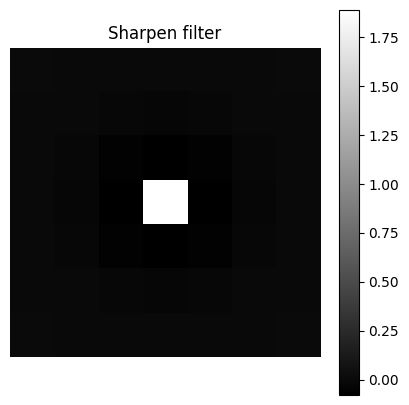

In [ ]:
# Visualize the sharpen filter
plt.figure(figsize=(5, 5)) # Create a new figure
plt.imshow(h_sharpen, cmap="gray")
plt.title("Sharpen filter")
plt.colorbar() # Add a colorbar
plt.axis("off")
plt.show() # Show the figure

In the visualization, the center of the filter is clearly dominant, while the surrounding area has lower values.

This confirms that the filter increases the importance of the central pixel and reduces the contribution of its neighbors. This behavior is what produces the sharpening effect when the filter is applied to the image.

Before applying the filter to the image, **the sums of the filter coefficients are checked.**

This step is useful because the sum of a filter gives information about its effect on the overall image brightness.

In [ ]:
# Print the sum of the Gaussian filter coefficients
# Since the Gaussian filter was normalized, this value should be approximately 1
print("Sum of Gaussian filter:", np.sum(h_gaussian))

# Print the sum of the identity filter coefficients
# This value is exactly 1 because only the central coefficient is equal to 1
print("Sum of Identity filter:", np.sum(h_identity))

# Print the sum of the sharpen filter coefficients
# This value should also be approximately 1, meaning that global brightness is preserved
print("Sum of Sharpen filter:", np.sum(h_sharpen))

Sum of Gaussian filter: 1.0
Sum of Identity filter: 1.0
Sum of Sharpen filter: 0.9999999999999999


The Gaussian filter has a sum equal to 1 because it was normalized. The identity filter also has a sum equal to 1, since it contains only one central coefficient equal to 1.

The sharpen filter also has a sum approximately equal to 1. This means that the filter enhances edges and details without strongly changing the global brightness of the image.

## Result Visualization

The sharpen filter is applied to the grayscale boat image using **convolution**.

During convolution, the filter is moved across the image, and each output pixel is computed by combining the corresponding input pixel with its neighborhood. Since the filter emphasizes local differences, the result should show clearer edges and more visible fine details.

In [ ]:
# Apply the sharpen filter to the grayscale boat image using 2D convolution
boat_sharpened = convolve2d(
    boat,                        # Input image to be filtered
    h_sharpen,                   # Filter applied to the image
    mode="same",                 # Keep the output image the same size as the input image
    boundary="symm"              # Use symmetric padding at the borders to reduce border artifacts
)

# Clip the pixel values to the valid range [0, 1]
# This is necessary because convolution can produce values below 0 or above 1
boat_sharpened = np.clip(boat_sharpened, 0, 1)

The original grayscale image and the sharpened grayscale image are displayed side by side.

This comparison allows us to observe the effect of the sharpening filter directly. The goal is not to completely transform the image, but **to** **make edges and fine structures more visible while keeping the result natural.**

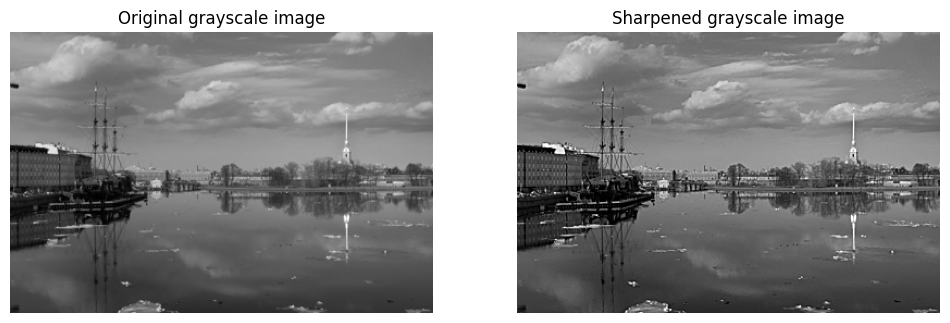

In [ ]:
# Visualize the result
plt.figure(figsize=(12, 6))

# Create the first subplot for the original image
plt.subplot(1, 2, 1)
plt.imshow(boat, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

# Create the second subplot for the sharpened image
plt.subplot(1, 2, 2)
plt.imshow(boat_sharpened, cmap="gray")
plt.title("Sharpened grayscale image")
plt.axis("off")

plt.show() # Show the comparison figure

The sharpened image shows a **moderate but visible enhancement of details.**

The effect is especially noticeable around the ship structure, the buildings, the church tower and the reflections on the water. These regions contain many edges and thin structures, so they are strongly affected by the sharpening filter.

At the same time, the image does not appear excessively artificial. This indicates that the chosen filter size and sigma value produce a balanced sharpening effect.

To better understand where the sharpening filter has the strongest effect, **a difference image is computed.**

The difference image is obtained by subtracting the original image from the sharpened image:

\\[\text{difference} = \text{boat}_{\text{sharpened}} - \text{boat}\\]

This visualization highlights the pixels that were modified the most by the filtering operation.

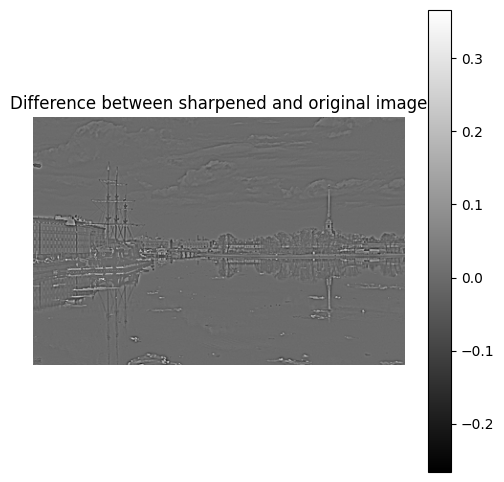

In [ ]:
# Compute the difference between the sharpened image and the original image
# This highlights the changes introduced by the sharpening filter
difference = boat_sharpened - boat

plt.figure(figsize=(6, 6))

# Display the difference image using a grayscale colormap
# Brighter and darker regions indicate stronger changes
plt.imshow(difference, cmap="gray")

plt.title("Difference between sharpened and original image")
plt.colorbar() # Add a colorbar
plt.axis("off") # Remove axis ticks and labels
plt.show() # Show the difference image

The difference image shows that the largest changes occur mainly around edges and fine details.

This is expected, because the sharpening filter is designed to enhance high-frequency components. In this image, the most affected areas are the ship, the buildings, the church tower, the clouds and the reflections on the water.

Smooth regions are less affected, which confirms that the filter mainly acts on local intensity variations rather than uniformly changing the whole image.

## Final Conclusion

In this assignment, a single sharpening filter was designed by combining a Gaussian filter and an identity filter.

The Gaussian filter represents the smoothing component, while the identity filter preserves the original image information. By subtracting the Gaussian filter from the identity filter and adding the result back to the identity filter, the final sharpen filter enhances edges and fine details.

**The result is balanced:** the sharpened image appears clearer and more detailed, especially around the ship, buildings and reflections, while the overall brightness and natural appearance of the image are preserved.